# Improvement : Combining multiple Methods


### Import data

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, StackingClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Load the cleaned dataset
california_data_cleaned = pd.read_csv('california_data_cleaned.csv')


In [ ]:

# Define bins and labels in strictly increasing order
bins = [0, 100000, 200000, 300000, 400000, california_data_cleaned['median_house_value'].max()]
labels = ['Low', 'Low_Medium', 'Medium', 'Medium-High', 'High']

# Create a new categorical column
california_data_cleaned['House_Value_Category'] = pd.cut(
    california_data_cleaned['median_house_value'], bins=bins, labels=labels
)

# Verify the distribution of the categories
print(california_data_cleaned['House_Value_Category'].value_counts())

House_Value_Category
Low_Medium     8026
Medium         4714
Low            3622
Medium-High    2000
High           1394
Name: count, dtype: int64


In [4]:

# Define features and target
X = california_data_cleaned.drop(columns=['median_house_value', 'House_Value_Category'])
y = california_data_cleaned['House_Value_Category']


In [ ]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
# Standardize the features


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
# List of models to evaluate



models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "SVM": SVC(probability=True, random_state=42),  # SVM with probabilities for later soft voting
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB()
}

# Initialize an empty list to store the results
results = []

In [ ]:



# Best hyperparameters for Random Forest found in part 3
best_rf_params = {
    'n_estimators': 200,
    'max_depth': None,
    'max_features': 'sqrt',
    'min_samples_split': 5,
    'min_samples_leaf': 1,
}

# Best hyperparameters for SVM found in part 3
best_svm_params = {
    'C': 100,         
    'gamma': 0.1,   
    'kernel': 'rbf',
}
best_lr_params = {
    'solver': 'lbfgs',  # Optimization algorithm
    'max_iter': 1000,   # Maximum number of iterations
    'random_state': 42
}

# List of models to evaluate
models = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(**best_rf_params, random_state=42),
    "SVM": SVC(**best_svm_params, probability=True, random_state=42),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Naive Bayes": GaussianNB(),
    "Logistic Regression" : LogisticRegression(**best_lr_params),

}

# Initialize an empty list to store the results
results = []

# Train and evaluate each model
for model_name, model in models.items():
    # Train the model
    model.fit(X_train_scaled, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test_scaled)
    
    # Compute performance metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average="weighted") 
    recall = recall_score(y_test, y_pred, average="weighted")      
    f1 = f1_score(y_test, y_pred, average="weighted")               
    
    # Append the results to the list
    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

# Create a DataFrame to display the results
results_df = pd.DataFrame(results)

print(results_df)


                 Model  Accuracy  Precision    Recall  F1-Score
0        Decision Tree  0.629808   0.626797  0.629808  0.628005
1        Random Forest  0.723937   0.721423  0.723937  0.718297
2                  SVM  0.693573   0.688881  0.693573  0.687334
3                  KNN  0.642713   0.634710  0.642713  0.633141
4          Naive Bayes  0.534666   0.524263  0.534666  0.524041
5  Logistic Regression  0.617156   0.608882  0.617156  0.598762


Naive bayes has overall very bad accuracy and precision , we decide to remove it for the voting. 

### Hard voting : 

In [ ]:



# Best hyperparameters for Random Forest
best_rf_params = {
    'n_estimators': 200,
    'max_depth': None,
    'max_features': 'sqrt',
    'min_samples_split': 5,
    'min_samples_leaf': 1,
}

# Best hyperparameters for SVM
best_svm_params = {
    'C': 10,
    'gamma': 0.1,
    'kernel': 'rbf',
}



# Define the base classifiers with best parameters
voting_estimators = [
    ('Decision Tree', DecisionTreeClassifier(random_state=42)),
    ('Random Forest', RandomForestClassifier(**best_rf_params, random_state=42)),
    ('SVM', SVC(**best_svm_params, probability=True, random_state=42)),  # Use probability=True for soft voting
    ('KNN', KNeighborsClassifier(n_neighbors=5)),
    ('Logistic Regression', LogisticRegression(**best_lr_params))
]

# Initialize the VotingClassifier with hard voting
voting_clf_hard = VotingClassifier(estimators=voting_estimators, voting='hard')

# Train the VotingClassifier
voting_clf_hard.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred_voting_hard = voting_clf_hard.predict(X_test_scaled)

# Compute accuracy for hard voting
accuracy_voting_hard = accuracy_score(y_test, y_pred_voting_hard)
print("Accuracy (Hard Voting):", accuracy_voting_hard)
print(classification_report(y_test, y_pred_voting_hard))


Accuracy (Hard Voting): 0.6966093117408907
              precision    recall  f1-score   support

        High       0.68      0.56      0.61       290
         Low       0.82      0.77      0.79       726
  Low_Medium       0.70      0.85      0.77      1540
      Medium       0.61      0.62      0.62       956
 Medium-High       0.66      0.29      0.40       440

    accuracy                           0.70      3952
   macro avg       0.69      0.62      0.64      3952
weighted avg       0.70      0.70      0.68      3952



### Soft voting : 

In [ ]:


# Define weights based on previous performance (example: weights proportional to F1-Score)
weights = [1, 4, 3, 1, 1]  # Decision Tree, Random Forest, SVM, KNN

# Initialize the VotingClassifier with soft voting and weights
voting_clf_soft = VotingClassifier(
    estimators=voting_estimators,
    voting='soft',  # Use soft voting to allow weighted probabilities
    weights=weights
)

# Train the VotingClassifier
voting_clf_soft.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred_voting_soft = voting_clf_soft.predict(X_test_scaled)

# Compute accuracy for soft voting
accuracy_voting_soft = accuracy_score(y_test, y_pred_voting_soft)
print("Accuracy (Soft Voting):", accuracy_voting_soft)
print(classification_report(y_test, y_pred_voting_soft))


Accuracy (Soft Voting): 0.7176113360323887
              precision    recall  f1-score   support

        High       0.73      0.53      0.61       290
         Low       0.84      0.77      0.80       726
  Low_Medium       0.72      0.86      0.78      1540
      Medium       0.65      0.64      0.64       956
 Medium-High       0.65      0.42      0.51       440

    accuracy                           0.72      3952
   macro avg       0.72      0.64      0.67      3952
weighted avg       0.72      0.72      0.71      3952



### Stacking :

Learns how to optimally combine predictions using a trained meta-model.

In [ ]:


stacking_clf = StackingClassifier(
    estimators=voting_estimators,
    final_estimator=LogisticRegression()
)
stacking_clf.fit(X_train_scaled, y_train)
y_pred_stacking = stacking_clf.predict(X_test_scaled)
print("Stacking Accuracy:", accuracy_score(y_test, y_pred_stacking))


Stacking Accuracy: 0.7302631578947368


## Visualization : 

Bar Chart: Quickly compare performance metrics across all models.

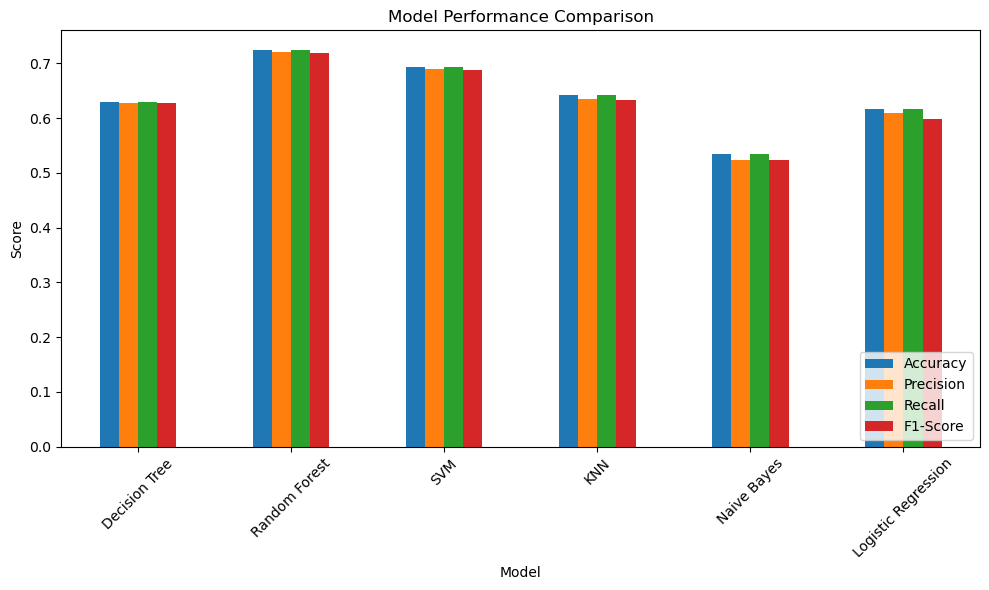

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

# 1. Bar Chart for Performance Metrics
results_df.set_index("Model", inplace=True)
results_df.plot(kind="bar", figsize=(10, 6))
plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


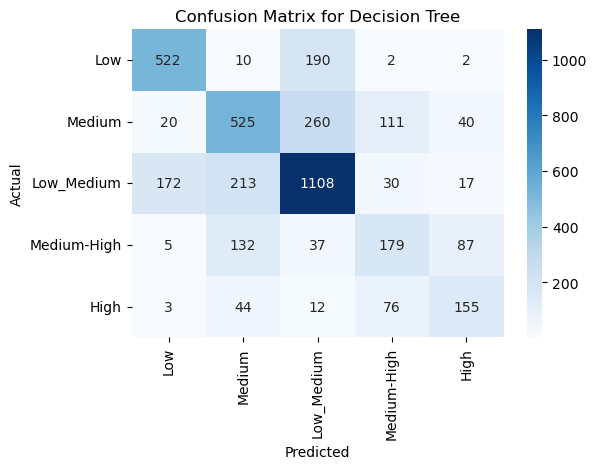

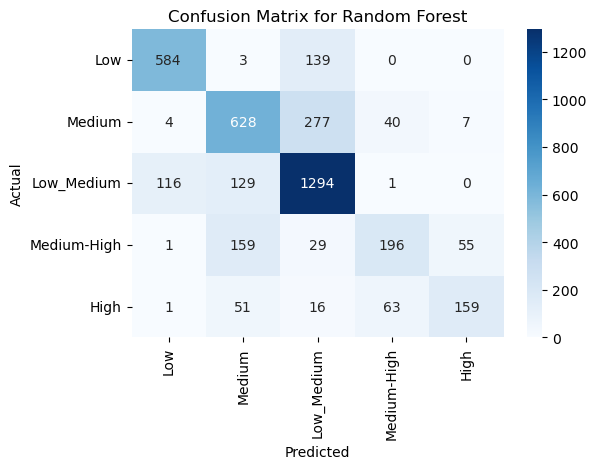

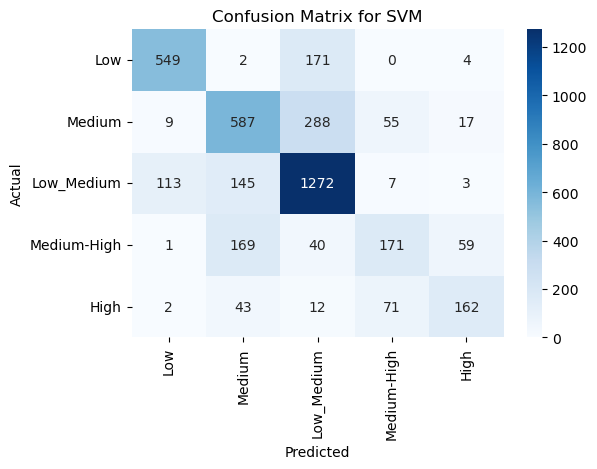

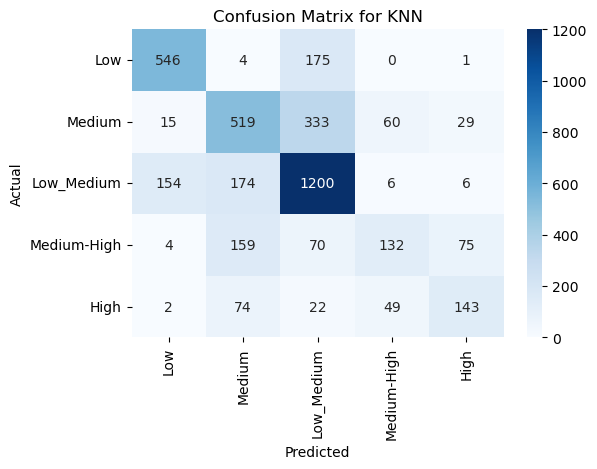

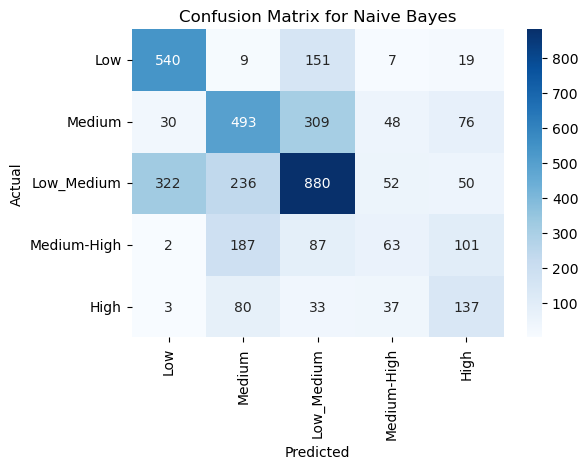

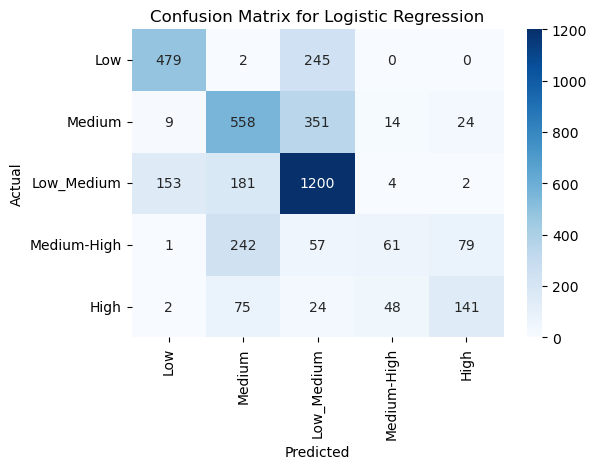

In [23]:

# 2. Confusion Matrix Heatmaps
for model_name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred, labels=y_test.unique())
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=y_test.unique(), yticklabels=y_test.unique())
    plt.title(f"Confusion Matrix for {model_name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

Significant misclassifications are observed in the following:

* "Low" being classified as "Low_Medium" 
* "Medium" being classified as "Low_Medium" 
* "Medium-High" being classified as "Medium" 

This indicates that the model struggles with neighboring categories, likely due to overlapping feature distributions. 

The confusion matrix suggests the model performs better for "Low_Medium" (the most populous class) but struggles with edge cases like "High" and "Low." We are going to try with less classes and try do balance them better to see a change in performance


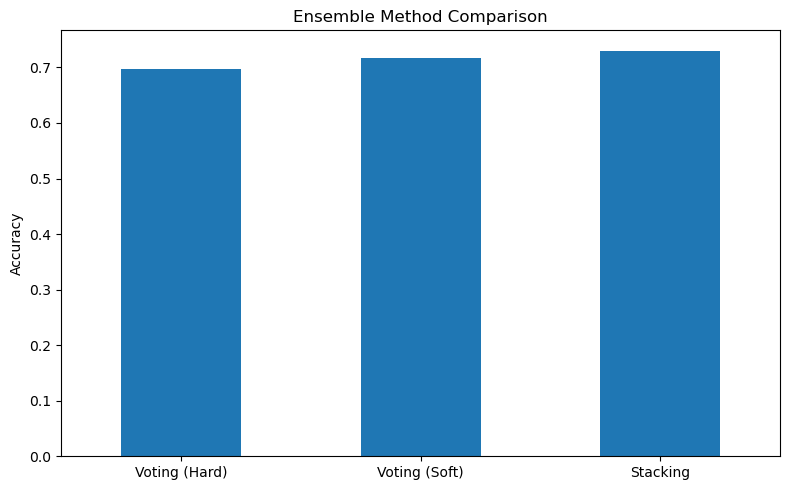

In [24]:
# 3. Ensemble Methods Comparison
ensemble_results = {
    "Voting (Hard)": accuracy_voting_hard,
    "Voting (Soft)": accuracy_voting_soft,
    "Stacking": accuracy_score(y_test, y_pred_stacking)
}
ensemble_df = pd.DataFrame(ensemble_results, index=["Accuracy"]).T
ensemble_df.plot(kind="bar", figsize=(8, 5), legend=False)
plt.title("Ensemble Method Comparison")
plt.ylabel("Accuracy")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

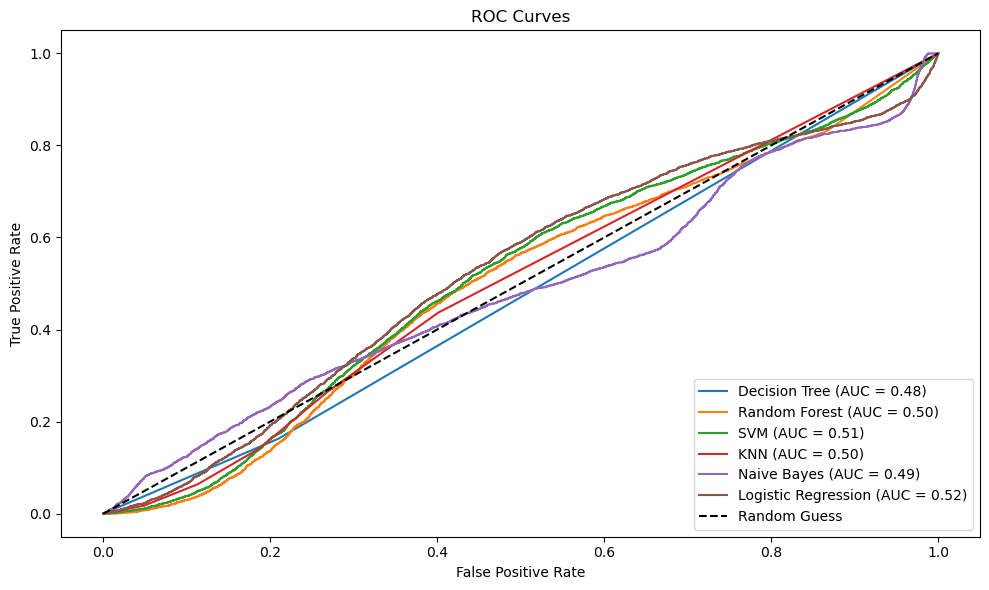

In [25]:


# 4. ROC Curves for Selected Models
plt.figure(figsize=(10, 6))
for model_name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_scaled)
        fpr, tpr, _ = roc_curve(pd.get_dummies(y_test).values.ravel(), y_prob.ravel())
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.2f})")
    elif hasattr(model, "decision_function"):
        y_score = model.decision_function(X_test_scaled)
        fpr, tpr, _ = roc_curve(pd.get_dummies(y_test).values.ravel(), y_score.ravel())
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", label="Random Guess")
plt.title("ROC Curves")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()
